# Exploration Notebook — The Fine Food Review Files

This notebook is the **interactive layer** of the project. The heavy lifting (cleaning, segmentation, sentiment, statistics) lives in the `python/` pipeline scripts — this notebook loads their exports and lets you poke at the results cell by cell, without re-running 40 minutes of work.

**Run the pipeline first** (see README §4), then: `uv run jupyter notebook notebooks/exploration.ipynb`

In [1]:
import json
from pathlib import Path

import pandas as pd

EXPORTS = Path("../exports")

kpis = json.loads((EXPORTS / "kpis.json").read_text())
segments = pd.read_csv(EXPORTS / "segment_summary.csv")
monthly = pd.read_csv(EXPORTS / "monthly_activity.csv")
sentiment = pd.read_csv(EXPORTS / "sentiment_by_score.csv")
gaps = pd.read_csv(EXPORTS / "gap_summary.csv")
advocates = pd.read_csv(EXPORTS / "advocates.csv")
audit = json.loads((EXPORTS / "wrangling_audit.json").read_text())

print(f"Clean reviews: {kpis['clean_reviews']:,}  |  Customers: {kpis['customers']:,}")
print(f"Sentiment-rating agreement: {kpis['sentiment_rating_agreement_pct']}%")

Clean reviews: 393,931  |  Customers: 256,059
Sentiment-rating agreement: 58.5%


## 1. The audit trail — what was removed and why

In [2]:
pd.DataFrame(audit)[["step", "rule", "reason", "rows_removed", "rows_after"]]

,step,rule,reason,rows_removed,rows_after
0,1,Drop rows where HelpfulnessNumerator > Helpful...,Structurally impossible: helpful votes are a s...,2,568452
1,2,"Deduplicate on (UserId, ProfileName, Time, Tex...",Cross-posted reviews would double-count custom...,174521,393931


## 2. Segment profiles — who are the six kinds of customer?

In [3]:
segments.style.format({"pct_customers": "{:.1f}%", "avg_score": "{:.2f}",
                        "avg_recency_days": "{:.0f}"})

,segment,customers,avg_reviews,avg_recency_days,avg_score,total_helpful_votes,pct_customers
0,Casual,122831,1.000000,596,4.15,203430,48.0%
1,Hibernating,43669,1.000000,1148,4.24,128304,17.1%
2,New / Promising,38348,1.000000,146,4.07,23344,15.0%
3,Champions,26295,4.540000,130,4.18,157471,10.3%
4,At Risk,14714,2.680000,1060,4.29,114031,5.7%
5,Loyal,10202,2.970000,416,4.23,56651,4.0%


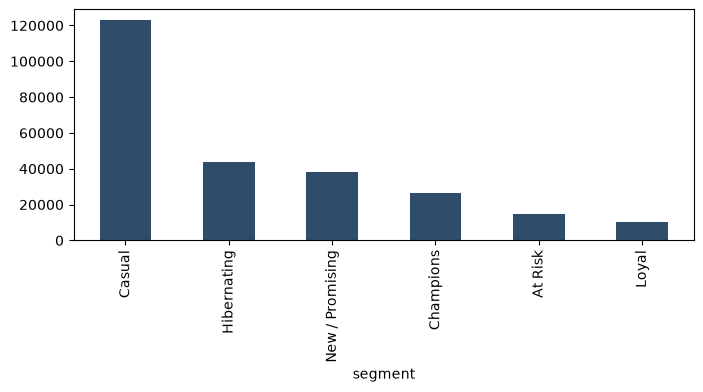

In [4]:
segments.plot(kind="bar", x="segment", y="customers", legend=False, figsize=(8, 3), color="#2f4d6b");

## 3. Retention timeline — new vs. active reviewers

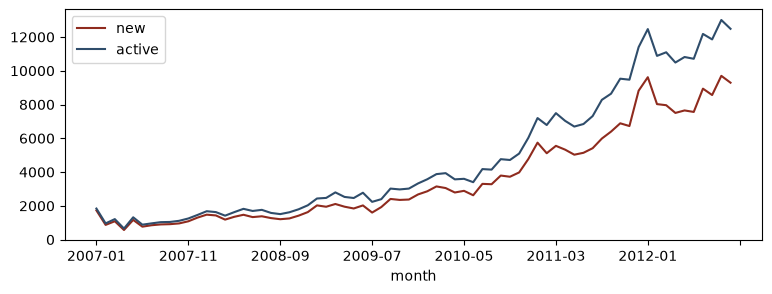

In [5]:
ax = monthly.plot(x="month", y="new_users", figsize=(9, 3), color="#8f2b1e", label="new")
monthly.plot(x="month", y="active_users", ax=ax, color="#2f4d6b", label="active");

## 4. Sentiment validation — do the words match the stars?

In [6]:
sentiment

,Score,reviews,avg_polarity,pct_positive,pct_neutral,pct_negative
0,1,36306,-0.153,12.3,53.3,34.4
1,2,20802,0.001,24.5,50.5,24.9
2,3,29769,0.163,44.1,43.1,12.8
3,4,56093,0.346,61.4,34.4,4.2
4,5,250961,0.456,65.9,31.3,2.7


In [7]:
# The off-diagonal story: hidden detractors and hidden advocates
gaps

,group,reviews,pct_of_high_star_reviews,avg_polarity
0,"Hidden detractors (4-5 stars, negative text)",9246,3.0,-0.331
1,"Hidden advocates (1-2 stars, positive text)",9573,NaN,0.443


## 5. Advocates — the activation shortlist

In [8]:
advocates.sort_values("advocacy_score", ascending=False).head(10)

,UserId,segment,review_count,avg_score,helpful_votes,helpfulness_ratio,pct_positive,advocacy_score,last_review
0,A3QDITMY3OOYRP,Loyal,23,4.83,45,0.957,95.652174,96.5,2011-05-24
1,AE4PE48Q2794I,Champions,18,4.94,35,1.000,94.444444,96.3,2012-09-13
2,A3OXHLG6DIBRW8,Champions,278,4.55,513,0.968,92.086331,96.0,2012-10-24
3,A3NEAETOSXDBOM,Champions,66,4.91,128,0.992,87.878788,96.0,2012-09-19
4,A1X1CEGHTHMBL1,Champions,72,4.85,26,1.000,84.722222,95.4,2012-10-20
5,AF72GTWZGAC61,Champions,41,4.71,146,0.980,87.804878,95.3,2012-07-18
6,AYB4ELCS5AM8P,Champions,66,4.79,189,0.969,89.393939,95.3,2012-09-20
7,A32B6A532454UD,Champions,17,4.82,11,1.000,94.117647,95.2,2012-08-16
8,AEP0XAC6F8N2Y,Champions,22,4.95,38,1.000,81.818182,94.5,2012-08-15
9,AO0HPTFIKQE9B,Champions,26,4.85,61,0.953,88.461538,94.2,2012-10-23


## 6. The skewness problem — why the classic tests were benched

The report's statistics chapter benches the classic t-test in favor of rank-based tests. This is the evidence. Run the cell below to see the three distributions live — the same figures the pipeline renders into the report. Notice how the **mean towers over the median** in each: that gap is the fingerprint of skew, and it is exactly why Mann-Whitney U (ranks) and Spearman (ranks) were chosen over the t-test and Pearson.

**The selection path used throughout the analysis:** define the objective → identify the data type (category or quantity) → count the variables involved → check each method's assumptions → ask whether observations are paired or independent. Skew breaks the t-test's and ANOVA's normality assumption, so every group comparison here goes rank-based (Mann-Whitney U for two groups; Kruskal-Wallis would be the pick for three or more). Categories get chi-square; drivers get OLS regression; the next experiment gets a power analysis. The full menu — including what was benched and why — is in the report's chooser table.


reviews per customer         skew  30.87   mean     1.54   median 1.00
helpful votes per customer   skew  27.69   mean     2.67   median 1.00
polarity per review          skew  -0.15   mean     0.34   median 0.30


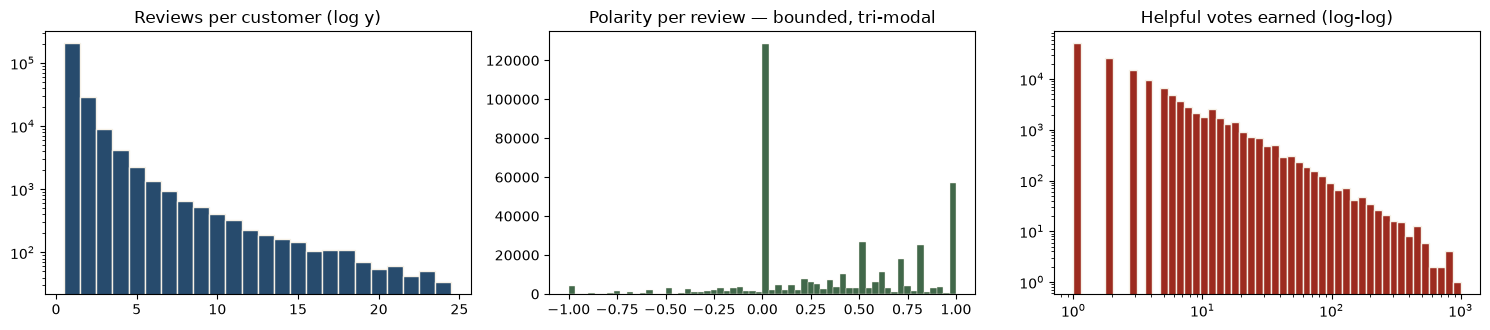

In [9]:
import numpy as np
import matplotlib.pyplot as plt

master = pd.read_csv(EXPORTS / "customer_master.csv")
reviews = pd.read_csv(EXPORTS / "reviews_scored.csv")

for label, s in [("reviews per customer", master["review_count"]),
                 ("helpful votes per customer", master["helpful_votes"]),
                 ("polarity per review", reviews["polarity"])]:
    print(f"{label:28s} skew {s.skew():6.2f}   mean {s.mean():8.2f}   median {s.median():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
axes[0].hist(master["review_count"], bins=np.arange(0.5, 25.5, 1), color="#274b6d", edgecolor="#f6f1e7")
axes[0].set_yscale("log"); axes[0].set_title("Reviews per customer (log y)")
axes[1].hist(reviews["polarity"], bins=60, color="#41684a", edgecolor="#f6f1e7", linewidth=0.3)
axes[1].set_title("Polarity per review — bounded, tri-modal")
voters = master[master["helpful_votes"] > 0]
axes[2].hist(voters["helpful_votes"], bins=np.logspace(0, 3, 50), color="#9c2b1f", edgecolor="#f6f1e7")
axes[2].set_xscale("log"); axes[2].set_yscale("log"); axes[2].set_title("Helpful votes earned (log-log)")
plt.tight_layout(); plt.show()

## 7. Your sandbox

Everything above is read-only exploration. If you want to dig into the **review-level** data, load the big export (regenerate it with stage 2 if needed):

```python
reviews = pd.read_csv(EXPORTS / "reviews_scored.csv")
reviews.groupby("segment")["polarity"].describe()
```